# Малая модель: cointegrated/rubert-tiny2

**Модель:** `cointegrated/rubert-tiny2` | **Параметры:** ~29M  
**Устройство:** Apple M4 (MPS) | **Датасет:** RuReviews 90K


## 1. Установка зависимостей

In [19]:
!pip install transformers==4.40.0 torch scikit-learn pandas matplotlib seaborn tqdm psutil

  Using cached transformers-4.40.0-py3-none-any.whl.metadata (137 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.19.1.tar.gz (321 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.40.0-py3-none-any.whl (9.0 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [93 lines of output]
      Running `maturin pep517 build-wheel -i /Users/daniilfedorov/Documents/univer/siibd/1/.venv/bin/python --compatibility off`
      Rust not found, installing into a temporary directory
      Python reports SOABI: cpython-313-darwin
      Computed rustc target triple: aarch64-apple-darwin
      Installation directory: /Users/daniilfedorov/Libr

## 2. Импорты и конфигурация

In [20]:
import os, time, random, re, warnings, psutil
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # для операций без MPS-поддержки — fallback на CPU
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

# M4 Mac: MPS (Metal) → иначе CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Устройство: {DEVICE}")

MODEL_NAME   = "cointegrated/rubert-tiny2"
MAX_LENGTH   = 128
BATCH_SIZE   = 64
EPOCHS       = 4
LR           = 3e-5
WARMUP_RATIO = 0.1
DATA_PATH    = "../data/rureviews.csv"
SAVE_DIR     = "./saved_model"
LABEL2ID     = {"negative": 0, "neautral": 1, "positive": 2}
ID2LABEL     = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS   = 3
CLASS_NAMES  = ["negative", "neautral", "positive"]

Устройство: mps


## 3. Загрузка и EDA

In [21]:
df = pd.read_csv(DATA_PATH, sep="\t")
print(f"Размер: {df.shape}")
display(df.head())

Размер: (90000, 2)


,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64


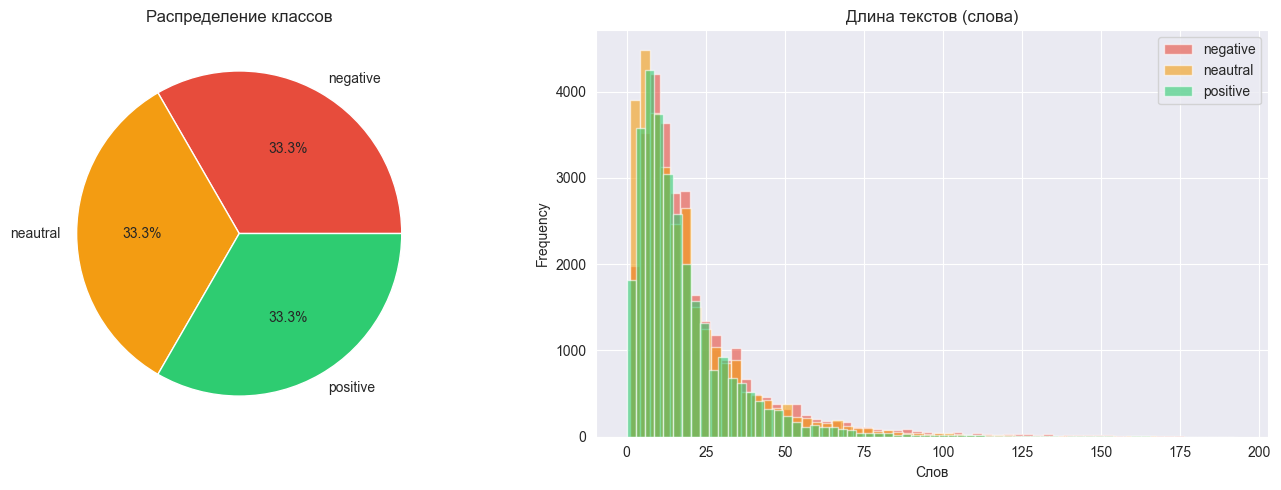

count    90000.000000
mean        20.011144
std         19.885001
min          0.000000
25%          8.000000
50%         14.000000
75%         25.000000
max        193.000000
Name: text_len, dtype: float64


In [22]:
print(df["sentiment"].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["sentiment"].value_counts().plot.pie(ax=axes[0], autopct="%1.1f%%",
    colors=["#e74c3c","#f39c12","#2ecc71"])
axes[0].set_title("Распределение классов"); axes[0].set_ylabel("")
df["text_len"] = df["review"].str.split().str.len()
for lbl, clr in zip(CLASS_NAMES, ["#e74c3c","#f39c12","#2ecc71"]):
    df[df["sentiment"]==lbl]["text_len"].plot.hist(ax=axes[1], bins=60, alpha=0.6, color=clr, label=lbl)
axes[1].set_title("Длина текстов (слова)"); axes[1].set_xlabel("Слов"); axes[1].legend()
plt.tight_layout(); plt.show()
print(df["text_len"].describe())

## 4. Предобработка и разбивка

In [23]:
def clean_text(t):
    t = re.sub(r"http\S+", "", str(t))
    return re.sub(r"\s+", " ", t).strip()

df["review_clean"] = df["review"].apply(clean_text)
df["label"]        = df["sentiment"].map(LABEL2ID)
df = df.dropna(subset=["review_clean","label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)
print(f"Записей: {len(df)}")

# tolist() вместо .values — избегает проблем sklearn с numpy object array
X = df["review_clean"].tolist()
y = df["label"].tolist()

X_train,X_tmp,y_train,y_tmp = train_test_split(X,y,test_size=0.2,random_state=SEED,stratify=y)
X_val,X_test,y_val,y_test   = train_test_split(X_tmp,y_tmp,test_size=0.5,random_state=SEED,stratify=y_tmp)
print(f"Train:{len(X_train)} Val:{len(X_val)} Test:{len(X_test)}")

Записей: 90000
Train:72000 Val:9000 Test:9000


## 5. Токенизация и DataLoader

In [24]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts, self.labels = texts, labels
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], max_length=MAX_LENGTH,
                        padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(),
                "attention_mask": enc["attention_mask"].squeeze(),
                "label": torch.tensor(self.labels[i], dtype=torch.long)}

train_ds = ReviewDataset(X_train, y_train)
val_ds   = ReviewDataset(X_val,   y_val)
test_ds  = ReviewDataset(X_test,  y_test)

# num_workers=0 и pin_memory=False — обязательно для MPS на macOS
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f"Батчей — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

Батчей — train:1125 val:141 test:141


## 6. Дообучение

In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {total_params:,}")

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)


Loading weights: 100%|██████████| 55/55 [00:00<00:00, 1263.21it/s, Materializing param=bert.pooler.dense.weight]                              
BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/archi

Параметров: 29,194,707


In [26]:
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(total_steps*WARMUP_RATIO),
    num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

### Тест на примерах ДО обучения

In [27]:
SAMPLE_REVIEWS = [
    ("Товар просто ужасный, развалился на второй день. Деньги выброшены на ветер!", "negative"),
    ("Пришло быстро, но качество так себе. Ожидал большего за эти деньги.", "neautral"),
    ("Отличный продукт! Заказываю уже третий раз, всегда доволен. Рекомендую всем!", "positive"),
    ("Совсем не то, что на картинке. Цвет другой, размер не совпадает.", "negative"),
    ("Нормально, ничего особенного. Пользуюсь, пока не сломалось.", "neautral"),
    ("Превзошло все ожидания! Качество на высоте, доставка молниеносная.", "positive"),
]

SEP = "=" * 60

def test_samples(mdl, label=""):
    mdl.eval()
    print(f"\n{SEP}")
    print(f"  {label}")
    print(SEP)
    results = []
    for text, true_label in SAMPLE_REVIEWS:
        enc = tokenizer(text, max_length=MAX_LENGTH, padding="max_length",
                        truncation=True, return_tensors="pt")
        with torch.no_grad():
            logits = mdl(input_ids=enc["input_ids"].to(DEVICE),
                         attention_mask=enc["attention_mask"].to(DEVICE)).logits
        probs = torch.softmax(logits, -1).cpu().squeeze().tolist()
        pred  = ID2LABEL[int(torch.tensor(probs).argmax())]
        conf  = max(probs) * 100
        status = "OK   " if pred == true_label else "WRONG"
        print(f"[{status}] {text[:65]}")
        print(f"        Истина: {true_label:<10} | Предсказано: {pred:<10} | Уверенность: {conf:.1f}%")
        print()
        results.append({"text": text, "true": true_label, "pred": pred,
                        "conf": conf, "correct": pred == true_label})
    n_correct = sum(r["correct"] for r in results)
    print(f"  Точность на примерах: {n_correct}/{len(results)} ({n_correct/len(results)*100:.0f}%)")
    return results

In [28]:
# Тест ДО обучения — голая предобученная модель, без fine-tuning
results_before = test_samples(model, label="ДО ОБУЧЕНИЯ (предобученная модель)")


  ДО ОБУЧЕНИЯ (предобученная модель)
[WRONG] Товар просто ужасный, развалился на второй день. Деньги выброшены
        Истина: negative   | Предсказано: neautral   | Уверенность: 33.5%

[WRONG] Пришло быстро, но качество так себе. Ожидал большего за эти деньг
        Истина: neautral   | Предсказано: negative   | Уверенность: 35.7%

[WRONG] Отличный продукт! Заказываю уже третий раз, всегда доволен. Реком
        Истина: positive   | Предсказано: negative   | Уверенность: 34.8%

[OK   ] Совсем не то, что на картинке. Цвет другой, размер не совпадает.
        Истина: negative   | Предсказано: negative   | Уверенность: 34.5%

[WRONG] Нормально, ничего особенного. Пользуюсь, пока не сломалось.
        Истина: neautral   | Предсказано: negative   | Уверенность: 35.5%

[WRONG] Превзошло все ожидания! Качество на высоте, доставка молниеносная
        Истина: positive   | Предсказано: negative   | Уверенность: 35.8%

  Точность на примерах: 1/6 (17%)


In [29]:
def train_epoch(model, loader):
    model.train()
    loss_sum, correct, n = 0.0, 0, 0
    for batch in tqdm(loader, desc="train", leave=False):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbl  = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        loss_sum += loss.item()*lbl.size(0)
        correct  += (out.logits.argmax(-1)==lbl).sum().item()
        n        += lbl.size(0)
    return loss_sum/n, correct/n

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    preds_all, labels_all = [], []
    for batch in tqdm(loader, desc="eval", leave=False):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbl  = batch["label"].to(DEVICE)
        out  = model(input_ids=ids, attention_mask=mask)
        loss_sum += criterion(out.logits, lbl).item()*lbl.size(0)
        p = out.logits.argmax(-1)
        correct  += (p==lbl).sum().item(); n += lbl.size(0)
        preds_all.extend(p.cpu().tolist()); labels_all.extend(lbl.cpu().tolist())
    return loss_sum/n, correct/n, f1_score(labels_all, preds_all, average="macro")

In [30]:
history = {k:[] for k in ["tl","vl","ta","va","vf1"]}
best_f1 = 0.0
os.makedirs(SAVE_DIR, exist_ok=True)

for epoch in range(1, EPOCHS+1):
    tl, ta = train_epoch(model, train_loader)
    vl, va, vf1 = eval_epoch(model, val_loader)
    for k,v in zip(["tl","vl","ta","va","vf1"],[tl,vl,ta,va,vf1]):
        history[k].append(v)
    print(f"Epoch {epoch}/{EPOCHS} | Train loss={tl:.4f} acc={ta:.4f} | Val loss={vl:.4f} acc={va:.4f} F1={vf1:.4f}")
    if vf1 > best_f1:
        best_f1 = vf1
        model.save_pretrained(SAVE_DIR); tokenizer.save_pretrained(SAVE_DIR)
        print(f"  -> Сохранена лучшая модель F1={best_f1:.4f}")

Epoch 1/4 | Train loss=0.7045 acc=0.6866 | Val loss=0.5576 acc=0.7520 F1=0.7539


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 20.41it/s]


  -> Сохранена лучшая модель F1=0.7539


Epoch 2/4 | Train loss=0.5402 acc=0.7624 | Val loss=0.5399 acc=0.7610 F1=0.7636


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 15.61it/s]


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 18.29it/s]


  -> Сохранена лучшая модель F1=0.7663


Epoch 4/4 | Train loss=0.4875 acc=0.7884 | Val loss=0.5327 acc=0.7669 F1=0.7685


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 18.33it/s]

  -> Сохранена лучшая модель F1=0.7685


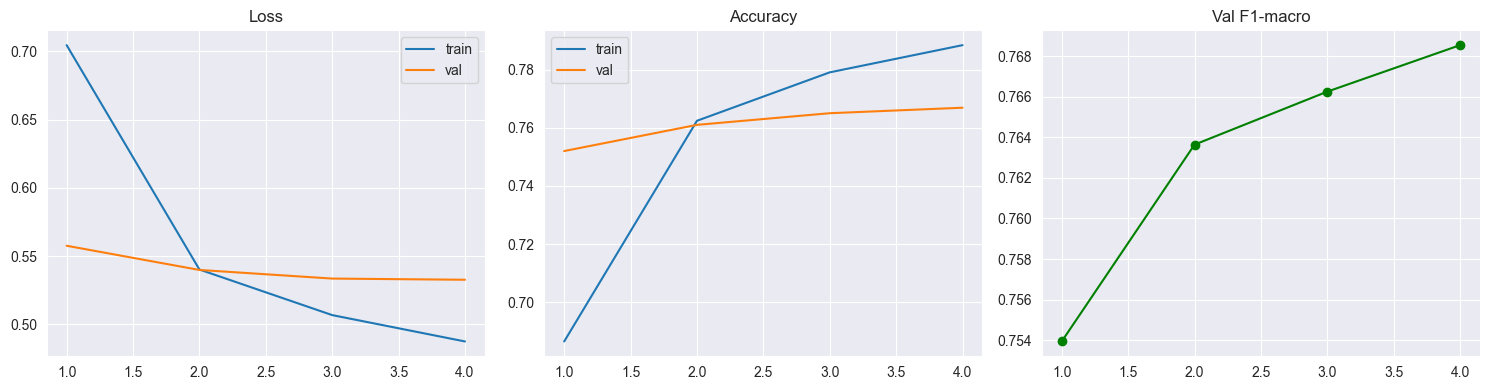

In [31]:
ep = range(1, EPOCHS+1)
fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].plot(ep, history["tl"], label="train"); ax[0].plot(ep, history["vl"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(ep, history["ta"], label="train"); ax[1].plot(ep, history["va"], label="val")
ax[1].set_title("Accuracy"); ax[1].legend()
ax[2].plot(ep, history["vf1"], marker="o", color="green")
ax[2].set_title("Val F1-macro")
plt.tight_layout(); plt.show()

## 7. Метрики на тестовой выборке

In [32]:
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)
model.eval(); print("Лучшая модель загружена")

Loading weights: 100%|██████████| 57/57 [00:00<00:00, 1605.96it/s, Materializing param=classifier.weight]                                     


Лучшая модель загружена


### Тест на примерах ПОСЛЕ обучения

In [33]:
# Тест ПОСЛЕ обучения — дообученная на RuReviews модель
results_after = test_samples(model, label="ПОСЛЕ ОБУЧЕНИЯ (дообученная на RuReviews)")


  ПОСЛЕ ОБУЧЕНИЯ (дообученная на RuReviews)
[OK   ] Товар просто ужасный, развалился на второй день. Деньги выброшены
        Истина: negative   | Предсказано: negative   | Уверенность: 95.1%

[OK   ] Пришло быстро, но качество так себе. Ожидал большего за эти деньг
        Истина: neautral   | Предсказано: neautral   | Уверенность: 70.4%

[OK   ] Отличный продукт! Заказываю уже третий раз, всегда доволен. Реком
        Истина: positive   | Предсказано: positive   | Уверенность: 99.4%

[WRONG] Совсем не то, что на картинке. Цвет другой, размер не совпадает.
        Истина: negative   | Предсказано: neautral   | Уверенность: 56.6%

[WRONG] Нормально, ничего особенного. Пользуюсь, пока не сломалось.
        Истина: neautral   | Предсказано: positive   | Уверенность: 83.5%

[OK   ] Превзошло все ожидания! Качество на высоте, доставка молниеносная
        Истина: positive   | Предсказано: positive   | Уверенность: 91.1%

  Точность на примерах: 4/6 (67%)


### Сравнение ДО / ПОСЛЕ

In [34]:
rows = []
for b, a in zip(results_before, results_after):
    rows.append({
        "Отзыв":          b["text"][:55] + "...",
        "Истина":         b["true"],
        "До":             b["pred"] + (" v" if b["correct"] else " x"),
        "После":          a["pred"] + (" v" if a["correct"] else " x"),
        "Уверен. до":     f'{b["conf"]:.1f}%',
        "Уверен. после":  f'{a["conf"]:.1f}%',
    })

cmp_df = pd.DataFrame(rows)
display(cmp_df)

acc_before = sum(r["correct"] for r in results_before) / len(results_before) * 100
acc_after  = sum(r["correct"] for r in results_after)  / len(results_after)  * 100
print(f"\nТочность ДО обучения:    {acc_before:.0f}%")
print(f"Точность ПОСЛЕ обучения: {acc_after:.0f}%")
print(f"Прирост:                 +{acc_after - acc_before:.0f}%")

,Отзыв,Истина,До,После,Уверен. до,Уверен. после
0,"Товар просто ужасный, развалился на второй ден...",negative,neautral x,negative v,33.5%,95.1%
1,"Пришло быстро, но качество так себе. Ожидал бо...",neautral,negative x,neautral v,35.7%,70.4%
2,"Отличный продукт! Заказываю уже третий раз, вс...",positive,negative x,positive v,34.8%,99.4%
3,"Совсем не то, что на картинке. Цвет другой, ра...",negative,negative v,neautral x,34.5%,56.6%
4,"Нормально, ничего особенного. Пользуюсь, пока ...",neautral,negative x,positive x,35.5%,83.5%
5,"Превзошло все ожидания! Качество на высоте, до...",positive,negative x,positive v,35.8%,91.1%



Точность ДО обучения:    17%
Точность ПОСЛЕ обучения: 67%
Прирост:                 +50%


In [35]:
@torch.no_grad()
def predict(loader):
    preds, labels, probs = [], [], []
    for batch in tqdm(loader, desc="predict"):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = model(input_ids=ids, attention_mask=mask)
        p    = torch.softmax(out.logits, -1).cpu().numpy()
        probs.extend(p); preds.extend(p.argmax(-1)); labels.extend(batch["label"].numpy())
    return np.array(preds), np.array(labels), np.array(probs)

y_pred, y_true, y_probs = predict(test_loader)

predict: 100%|██████████| 141/141 [00:08<00:00, 16.36it/s]


In [36]:
acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average="macro")
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
y_bin = label_binarize(y_true, classes=[0,1,2])
roc   = roc_auc_score(y_bin, y_probs, average="macro", multi_class="ovr")
print(f"Accuracy : {acc:.4f}")
print(f"F1-macro : {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(); print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Accuracy : 0.7700
F1-macro : 0.7718
Precision: 0.7754
Recall   : 0.7700
ROC-AUC  : 0.9129

              precision    recall  f1-score   support

    negative       0.77      0.72      0.74      3000
    neautral       0.65      0.72      0.68      3000
    positive       0.91      0.87      0.89      3000

    accuracy                           0.77      9000
   macro avg       0.78      0.77      0.77      9000
weighted avg       0.78      0.77      0.77      9000



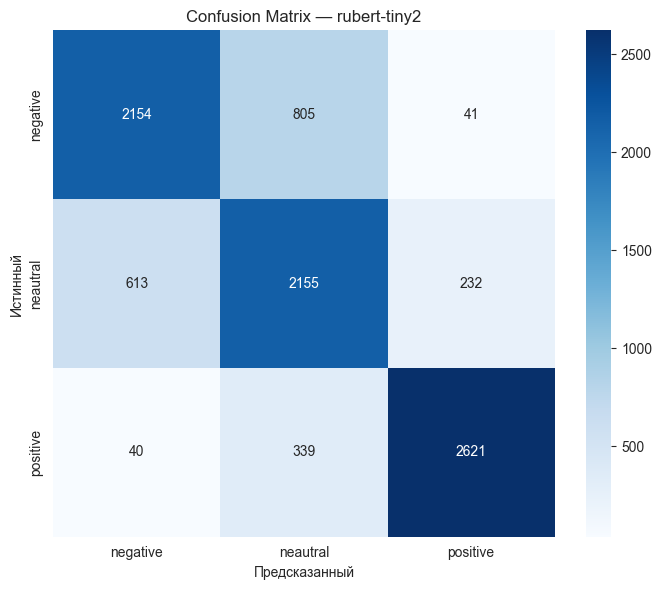

In [37]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — rubert-tiny2")
plt.ylabel("Истинный"); plt.xlabel("Предсказанный")
plt.tight_layout(); plt.show()

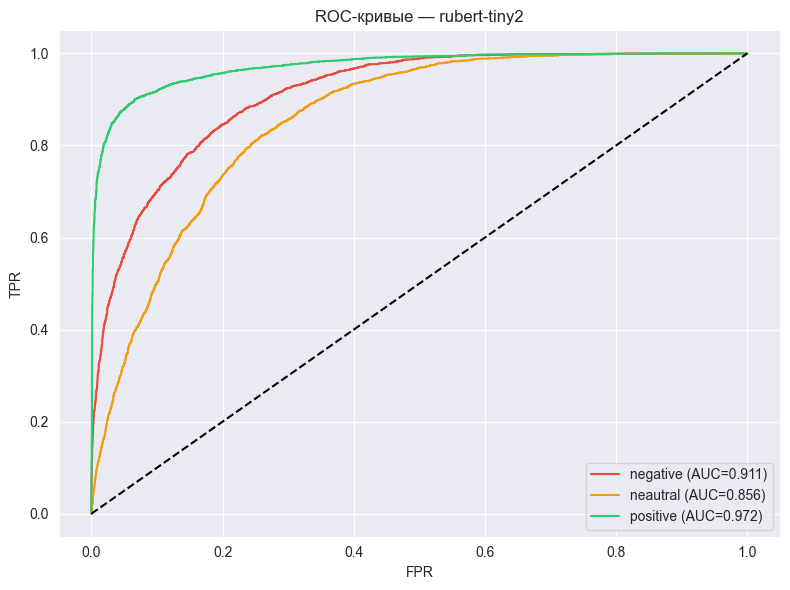

In [38]:
fig, ax = plt.subplots(figsize=(8,6))
for i,(cls,clr) in enumerate(zip(CLASS_NAMES,["#e74c3c","#f39c12","#2ecc71"])):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_probs[:,i])
    ax.plot(fpr, tpr, color=clr, label=f"{cls} (AUC={auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],"k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC-кривые — rubert-tiny2"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Время инференса и потребление памяти

In [39]:
model.eval()
wb = next(iter(test_loader))
# прогрев MPS
for _ in range(3):
    with torch.no_grad():
        model(input_ids=wb["input_ids"].to(DEVICE), attention_mask=wb["attention_mask"].to(DEVICE))

# MPS синхронизация перед замером
if DEVICE.type == "mps": torch.mps.synchronize()
t0 = time.perf_counter()
with torch.no_grad():
    for batch in test_loader:
        model(input_ids=batch["input_ids"].to(DEVICE), attention_mask=batch["attention_mask"].to(DEVICE))
if DEVICE.type == "mps": torch.mps.synchronize()

elapsed = time.perf_counter() - t0
ms_per  = elapsed / len(test_ds) * 1000
sps     = len(test_ds) / elapsed
print(f"Всего: {elapsed:.2f}с | Пример: {ms_per:.3f}мс | Скорость: {sps:.1f} примеров/с")

Всего: 8.19с | Пример: 0.910мс | Скорость: 1098.8 примеров/с


In [40]:
proc   = psutil.Process(os.getpid())
ram_mb = proc.memory_info().rss / 1024**2
w_mb   = sum(p.numel()*p.element_size() for p in model.parameters()) / 1024**2
print(f"RAM процесса  : {ram_mb:.1f} МБ")
print(f"Размер весов  : {w_mb:.1f} МБ")
if DEVICE.type == "mps":
    mps_mb = torch.mps.current_allocated_memory() / 1024**2
    print(f"MPS выделено  : {mps_mb:.1f} МБ")

RAM процесса  : 1100.5 МБ
Размер весов  : 111.4 МБ
MPS выделено  : 582.1 МБ


## 9. Итоговая таблица

In [41]:
summary = pd.DataFrame([
    ("Модель",              MODEL_NAME),
    ("Параметры (M)",       f"{total_params/1e6:.1f}"),
    ("Accuracy",            f"{acc:.4f}"),
    ("F1-macro",            f"{f1:.4f}"),
    ("Precision-macro",     f"{prec:.4f}"),
    ("Recall-macro",        f"{rec:.4f}"),
    ("ROC-AUC macro-OvR",   f"{roc:.4f}"),
    ("Время/пример (мс)",   f"{ms_per:.3f}"),
    ("Примеров/сек",        f"{sps:.1f}"),
    ("RAM процесса (МБ)",   f"{ram_mb:.1f}"),
    ("Размер весов (МБ)",   f"{w_mb:.1f}"),
], columns=["Метрика", "Значение"])
display(summary)

,Метрика,Значение
0,Модель,cointegrated/rubert-tiny2
1,Параметры (M),29.2
2,Accuracy,0.7700
3,F1-macro,0.7718
4,Precision-macro,0.7754
5,Recall-macro,0.7700
6,ROC-AUC macro-OvR,0.9129
7,Время/пример (мс),0.910
8,Примеров/сек,1098.8
9,RAM процесса (МБ),1100.5
